# Diamond Price — Model Building

Train and compare 7 regression models on the cleaned diamonds dataset (~54k rows). With this much data, tree ensembles dominate — but we still report linear baselines for honesty.

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

import sys
sys.path.append(".")
from utils import (evaluate_model, plot_actual_vs_predicted, plot_residuals,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = pd.read_csv("data/diamonds_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (53920, 13)


,carat,cut,color,clarity,depth,table,price,x,y,z,volume,density,log_carat
0,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43,38.202030,0.006021,0.207014
1,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31,34.505856,0.006086,0.190620
2,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31,38.076885,0.006040,0.207014
3,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63,46.724580,0.006207,0.254642
4,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75,51.917250,0.005971,0.270027


## 2. Train / Test Split + Scaling

In [3]:
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train mean price: ${y_train.mean():,.0f}, Test mean: ${y_test.mean():,.0f}")

Train: (43136, 12), Test: (10784, 12)
Train mean price: $3,927, Test mean: $3,949


## 3. Model 1 — Linear Regression


  Linear Regression
  R2    : 0.6881
  RMSE  : 2236.0041
  MAE   : 800.2764
  MAPE  : 0.4352


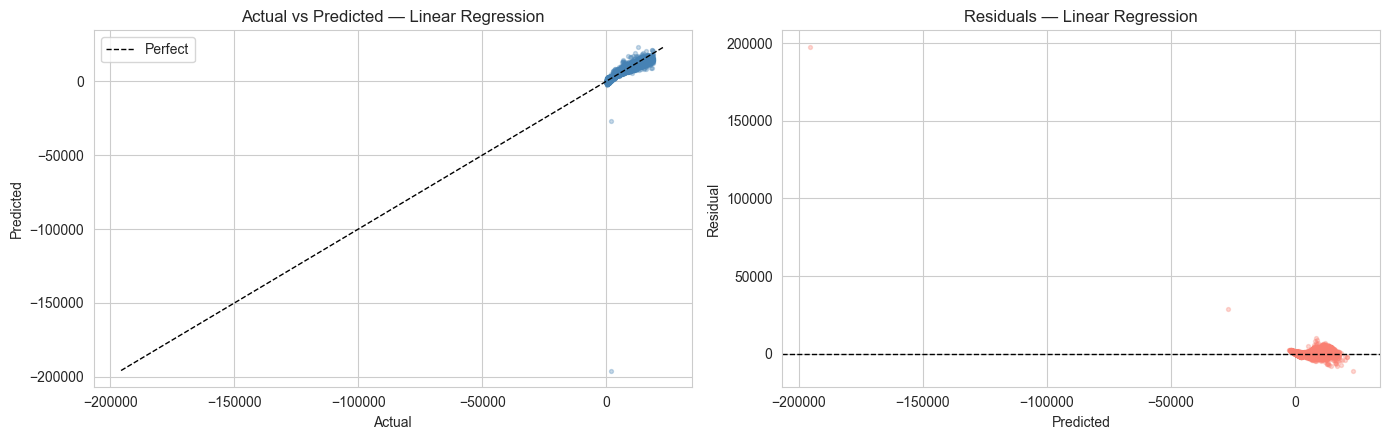

In [4]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
m_lr = evaluate_model("Linear Regression", y_test, pred_lr)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_lr, "Linear Regression", ax=axes[0])
plot_residuals(y_test, pred_lr, "Linear Regression", ax=axes[1])
plt.tight_layout(); plt.show()

## 4. Model 2 — Ridge


  Ridge
  R2    : 0.7058
  RMSE  : 2171.7899
  MAE   : 798.2935
  MAPE  : 0.4337


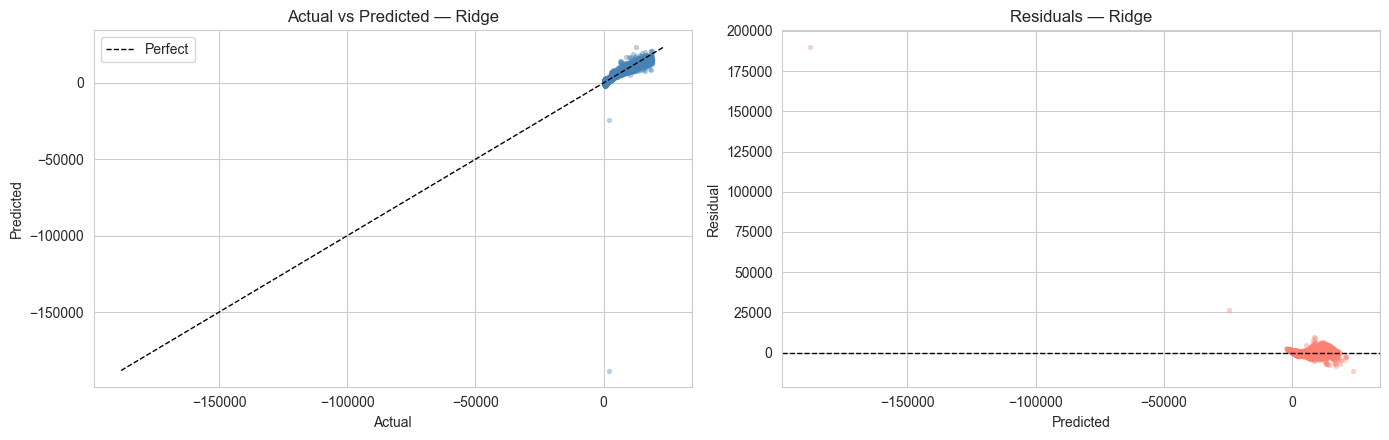

In [5]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_s, y_train)
pred_ridge = ridge.predict(X_test_s)
m_ridge = evaluate_model("Ridge", y_test, pred_ridge)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_ridge, "Ridge", ax=axes[0])
plot_residuals(y_test, pred_ridge, "Ridge", ax=axes[1])
plt.tight_layout(); plt.show()

## 5. Model 3 — Lasso


  Lasso
  R2    : 0.9121
  RMSE  : 1187.2552
  MAE   : 802.8037
  MAPE  : 0.4373


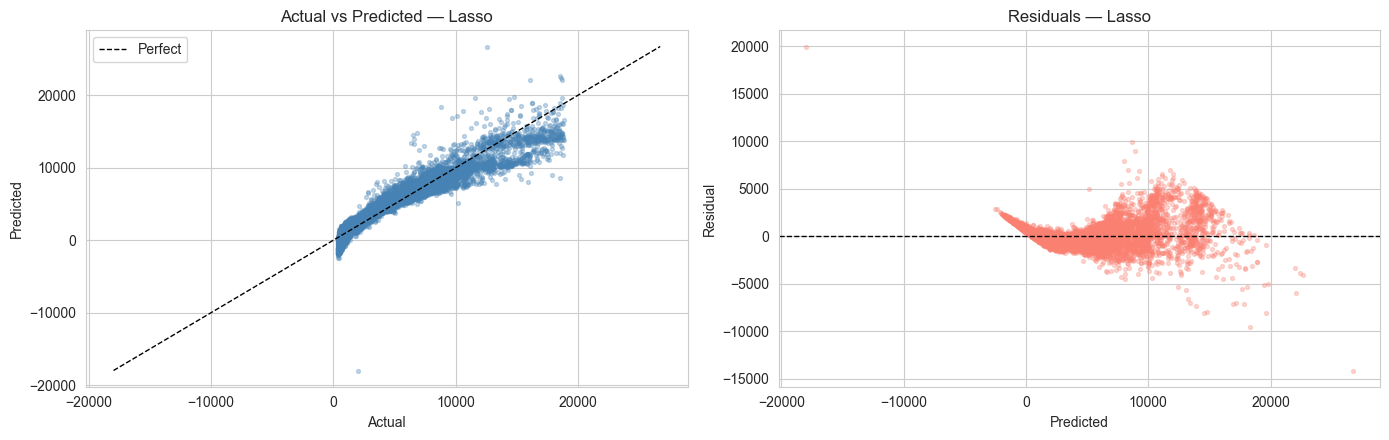

In [6]:
lasso = Lasso(alpha=10.0, random_state=42, max_iter=10000)
lasso.fit(X_train_s, y_train)
pred_lasso = lasso.predict(X_test_s)
m_lasso = evaluate_model("Lasso", y_test, pred_lasso)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_lasso, "Lasso", ax=axes[0])
plot_residuals(y_test, pred_lasso, "Lasso", ax=axes[1])
plt.tight_layout(); plt.show()

## 6. Model 4 — Decision Tree


  Decision Tree
  R2    : 0.9753
  RMSE  : 629.4851
  MAE   : 318.3137
  MAPE  : 0.0864


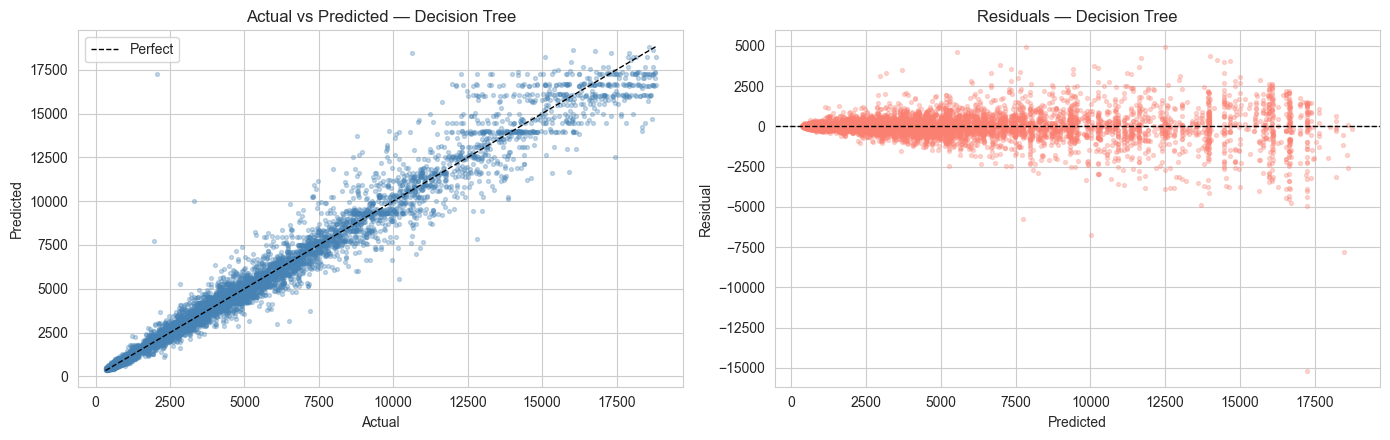

In [7]:
dt = DecisionTreeRegressor(random_state=42, max_depth=12)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
m_dt = evaluate_model("Decision Tree", y_test, pred_dt)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_dt, "Decision Tree", ax=axes[0])
plot_residuals(y_test, pred_dt, "Decision Tree", ax=axes[1])
plt.tight_layout(); plt.show()

## 7. Model 5 — Random Forest


  Random Forest
  R2    : 0.9820
  RMSE  : 537.0172
  MAE   : 260.1742
  MAPE  : 0.0638


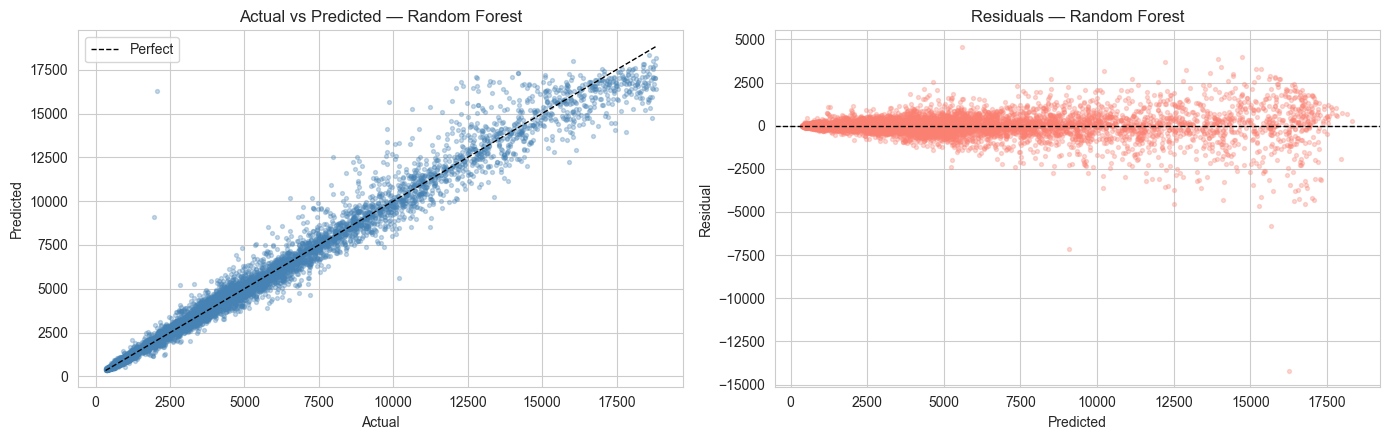

In [8]:
rf = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
m_rf = evaluate_model("Random Forest", y_test, pred_rf)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_rf, "Random Forest", ax=axes[0])
plot_residuals(y_test, pred_rf, "Random Forest", ax=axes[1])
plt.tight_layout(); plt.show()

## 8. Model 6 — Gradient Boosting


  Gradient Boosting
  R2    : 0.9827
  RMSE  : 527.0058
  MAE   : 271.1712
  MAPE  : 0.0748


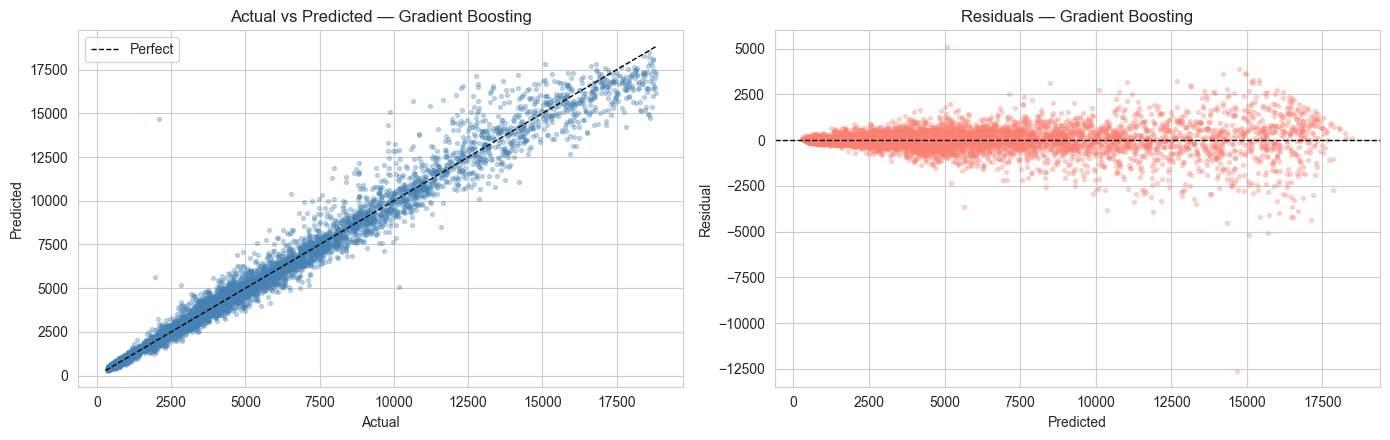

In [9]:
gb = GradientBoostingRegressor(random_state=42, n_estimators=200, max_depth=5)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_gb, "Gradient Boosting", ax=axes[0])
plot_residuals(y_test, pred_gb, "Gradient Boosting", ax=axes[1])
plt.tight_layout(); plt.show()

## 9. Model 7 — KNN (with K optimization)

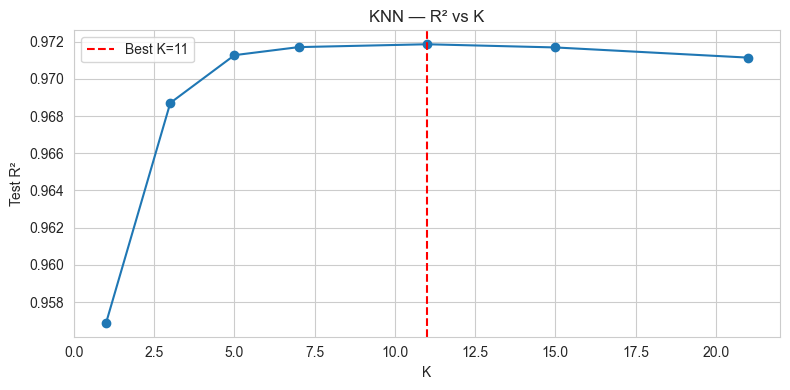


  KNN (K=11)
  R2    : 0.9719
  RMSE  : 671.6935
  MAE   : 362.0823
  MAPE  : 0.1007


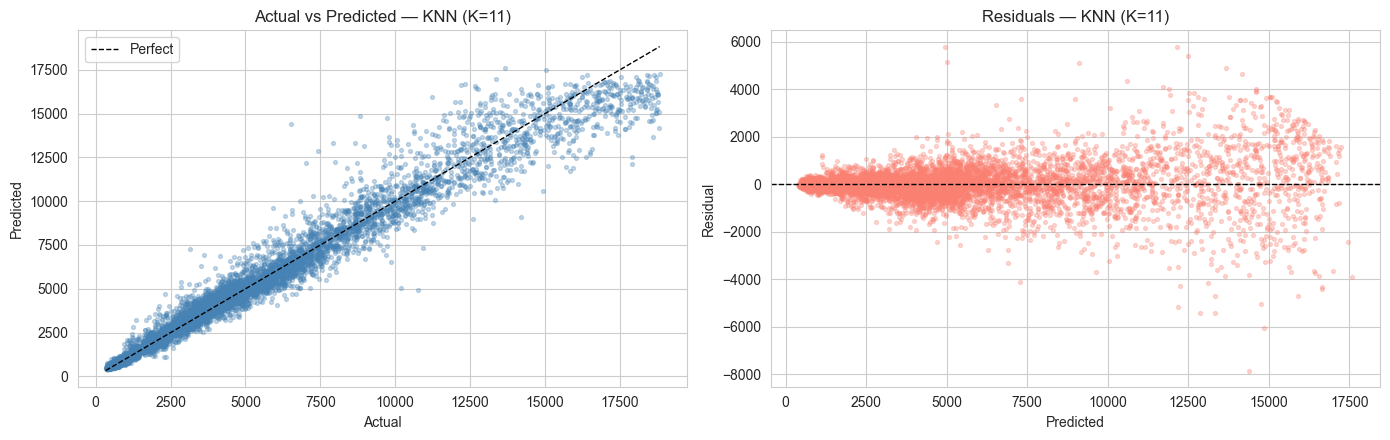

In [10]:
ks = [1, 3, 5, 7, 11, 15, 21]
r2s = []
for k in ks:
    kk = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    kk.fit(X_train_s, y_train)
    r2s.append(kk.score(X_test_s, y_test))
best_k = ks[int(np.argmax(r2s))]
plt.figure(figsize=(8, 4))
plt.plot(ks, r2s, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best K={best_k}")
plt.xlabel("K"); plt.ylabel("Test R²"); plt.title("KNN — R² vs K")
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_s, y_train)
pred_knn = knn.predict(X_test_s)
m_knn = evaluate_model(f"KNN (K={best_k})", y_test, pred_knn)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_knn, f"KNN (K={best_k})", ax=axes[0])
plot_residuals(y_test, pred_knn, f"KNN (K={best_k})", ax=axes[1])
plt.tight_layout(); plt.show()

## 10. Feature Importance (tree-based)

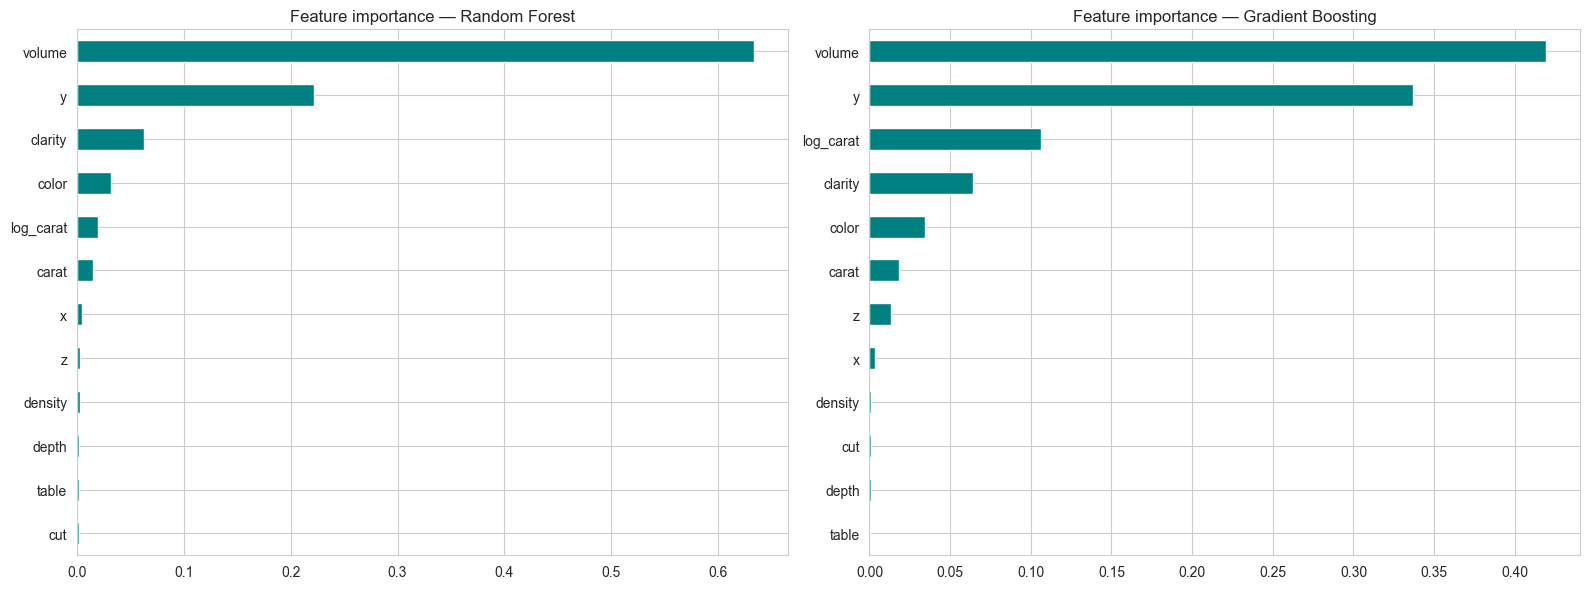

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], gb, "Gradient Boosting")]:
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    imp.plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"Feature importance — {name}")
plt.tight_layout(); plt.show()

## 11. Model Comparison

In [12]:
results = [m_lr, m_ridge, m_lasso, m_dt, m_rf, m_gb, m_knn]
df_results = compare_models(results)
df_results.round(4)

,Model,R2,RMSE,MAE,MAPE
0,Gradient Boosting,0.9827,527.0058,271.1712,0.0748
1,Random Forest,0.9820,537.0172,260.1742,0.0638
2,Decision Tree,0.9753,629.4851,318.3137,0.0864
3,KNN (K=11),0.9719,671.6935,362.0823,0.1007
4,Lasso,0.9121,1187.2552,802.8037,0.4373
5,Ridge,0.7058,2171.7899,798.2935,0.4337
6,Linear Regression,0.6881,2236.0041,800.2764,0.4352


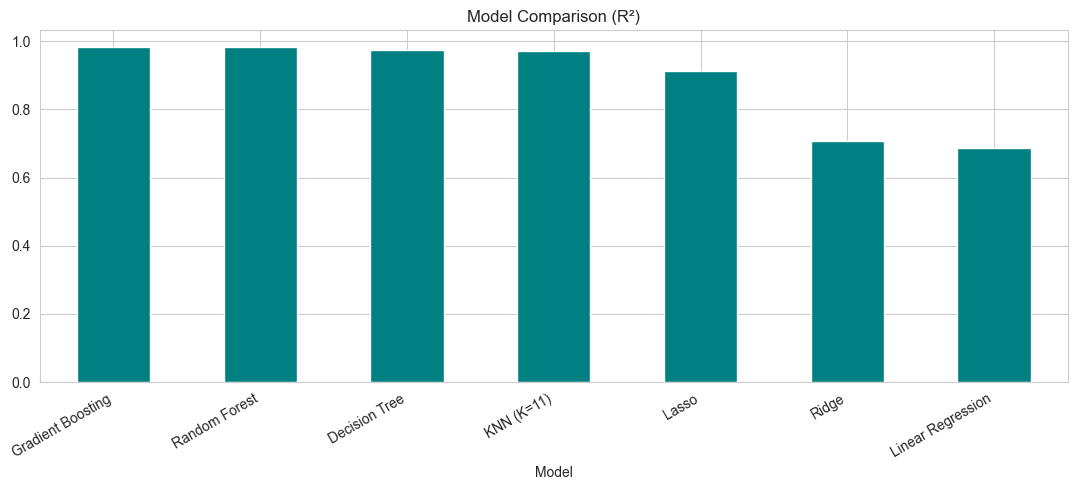

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
df_results.set_index("Model")[["R2"]].plot(kind="bar", ax=ax, color="teal", legend=False)
ax.set_title("Model Comparison (R²)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

## 12. 5-Fold Cross-Validation

In [14]:
cv_models = {
    "Linear Regression": (lr, X_train_s),
    "Ridge":             (ridge, X_train_s),
    "Lasso":             (lasso, X_train_s),
    "Decision Tree":     (dt, X_train),
    "Random Forest":     (rf, X_train),
    "Gradient Boosting": (gb, X_train),
    f"KNN (K={best_k})": (knn, X_train_s),
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, y_train, cv=5, scoring="r2")


Linear Regression
  CV r2 : [ 0.9092  0.9096  0.9119  0.9131 -0.7873]
  Mean      : 0.5713 (+/- 0.6793)

Ridge
  CV r2 : [ 0.909   0.9097  0.9119  0.9132 -0.4028]
  Mean      : 0.6482 (+/- 0.5255)

Lasso


  CV r2 : [0.9009 0.9054 0.9055 0.9081 0.5679]
  Mean      : 0.8376 (+/- 0.1348)

Decision Tree


  CV r2 : [0.9716 0.9732 0.971  0.9736 0.9717]
  Mean      : 0.9722 (+/- 0.0010)

Random Forest


  CV r2 : [0.9807 0.9814 0.9796 0.9822 0.9803]
  Mean      : 0.9808 (+/- 0.0009)

Gradient Boosting


  CV r2 : [0.9814 0.9822 0.9818 0.9826 0.9811]
  Mean      : 0.9818 (+/- 0.0005)

KNN (K=11)


  CV r2 : [0.9679 0.9675 0.9645 0.9693 0.968 ]
  Mean      : 0.9674 (+/- 0.0016)


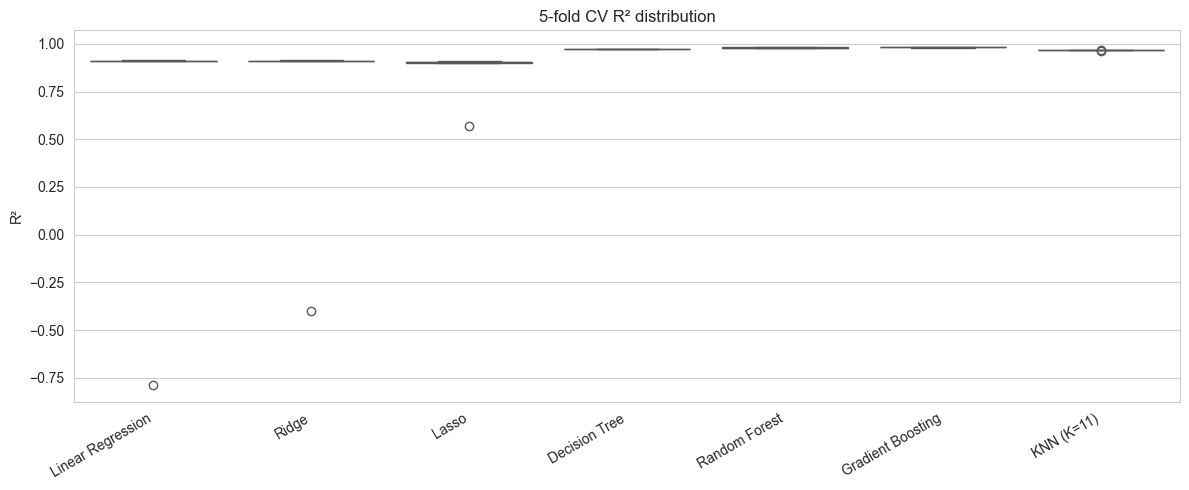

In [15]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize=(12, 5))
sns.boxplot(data=cv_df, palette="Set2")
plt.title("5-fold CV R² distribution")
plt.xticks(rotation=30, ha="right"); plt.ylabel("R²")
plt.tight_layout(); plt.show()

## 13. Hyperparameter Tuning — Random Forest (small grid)

In [16]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth":    [None, 15, 20],
    "min_samples_leaf": [1, 3],
}
grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                    param_grid, cv=3, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)
print(f"Best params : {grid.best_params_}")
print(f"Best CV R²  : {grid.best_score_:.4f}")

Best params : {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV R²  : 0.9804



  Random Forest (Tuned)
  R2    : 0.9820
  RMSE  : 536.6566
  MAE   : 262.6893
  MAPE  : 0.0662


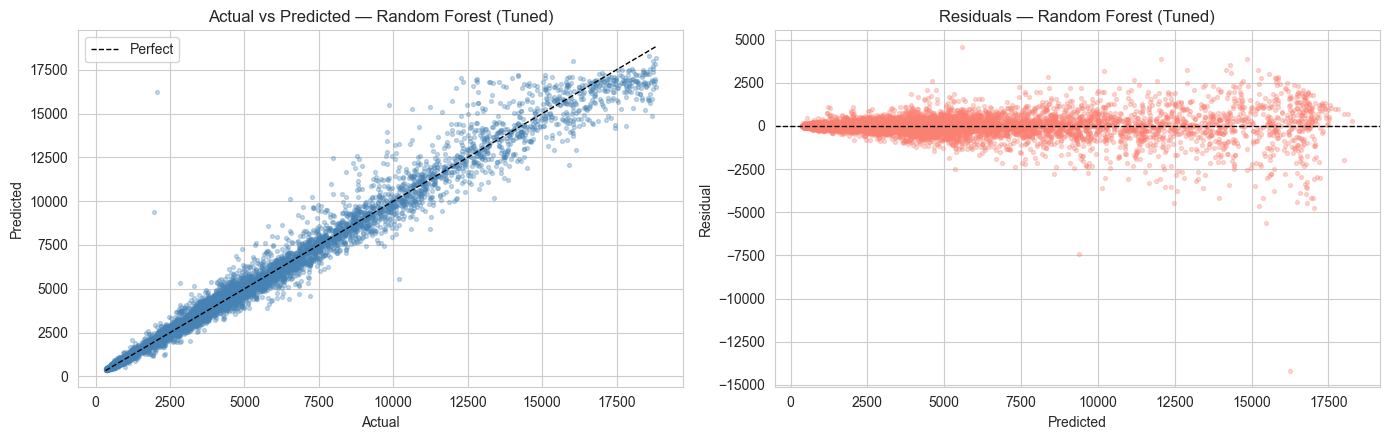

In [17]:
rf_tuned = grid.best_estimator_
pred_rf_t = rf_tuned.predict(X_test)
m_rf_t = evaluate_model("Random Forest (Tuned)", y_test, pred_rf_t)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_actual_vs_predicted(y_test, pred_rf_t, "Random Forest (Tuned)", ax=axes[0])
plot_residuals(y_test, pred_rf_t, "Random Forest (Tuned)", ax=axes[1])
plt.tight_layout(); plt.show()

## 14. Tuned Feature Importance

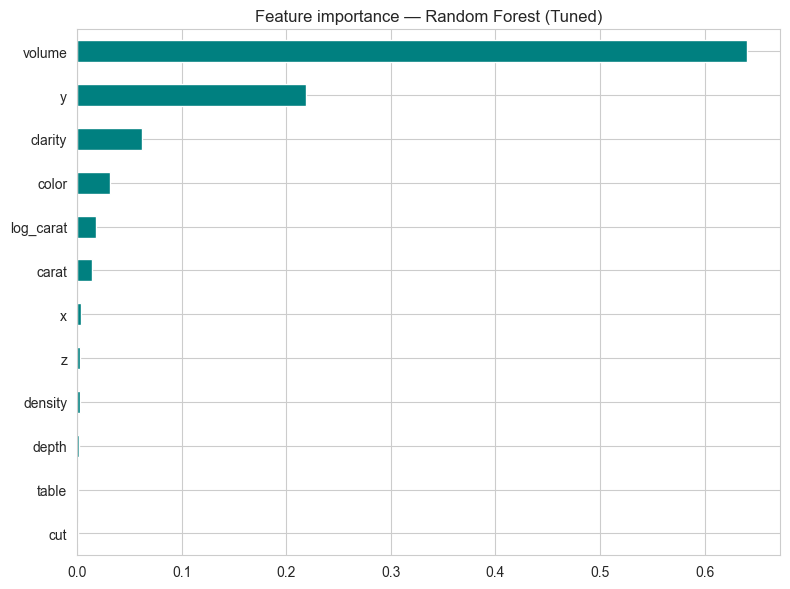

In [18]:
imp = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
imp.plot(kind="barh", color="teal")
plt.title("Feature importance — Random Forest (Tuned)")
plt.tight_layout(); plt.show()

## 15. Prediction Example

In [19]:
sample = X_test.iloc[[0, 1, 2]]
preds = rf_tuned.predict(sample)
for i, (idx, _) in enumerate(sample.iterrows()):
    actual = y_test.loc[idx]
    print(f"Sample {i}: actual=${actual:>7,.0f}   predicted=${preds[i]:>7,.0f}   error=${preds[i]-actual:+,.0f}")

Sample 0: actual=$    874   predicted=$  1,067   error=$+193
Sample 1: actual=$  9,273   predicted=$  8,091   error=$-1,182
Sample 2: actual=$ 11,743   predicted=$ 11,092   error=$-651


## 16. Final Summary

| Aspect | Result |
|--------|--------|
| Best baseline by R² | Random Forest / Gradient Boosting (R² ≈ 0.98) |
| Tuned model | Random Forest tuned via `GridSearchCV` (3-fold to keep cost manageable) |
| Top features | `carat`, `y`, `volume`, `x`, `clarity` |
| Caveats | Linear models cap at R² ≈ 0.92 because of severe multicollinearity (carat ↔ x ↔ y ↔ z); consider log-target + interaction terms for them |

### Next Steps
- **Log-transform `price`** before fitting linear models — it should add ~3-4 R² points.
- Try **gradient-boosted trees on the residuals** of a log-linear model (mixture-of-experts).
- Investigate the **Simpson-style trade-off** between carat and quality (cut/color/clarity) using partial-dependence plots.